# NEOFC - Application in drug challenge data

In [1]:
from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sn
import seaborn.objects as so
import warnings
import seaborn as sn
import seaborn.objects as so
import statsmodels.formula.api as smf
from tqdm.auto import tqdm

from utils import load_neofc_stats, load_sac_gc, meff_li_ji, sidak

# working directory
wd = Path.cwd() 
print(wd)

# general vars
from utils import (REF_GROUPS, REF_GROUPS_COLORS, REF_GROUPNAMES_PET, REF_NAMES_PET, REF_GROUPS_PET,
                   REF_MATH_NAMES)

# colors
colors = REF_GROUPS_COLORS[1:]
colors_maps = [c for i, v in enumerate(REF_GROUPS_PET.values()) for c in [colors[i]]*len(v)]
colors_by_map = {}
for group, color in zip(REF_GROUPS, REF_GROUPS_COLORS):
    for m in REF_GROUPS[group]:
        colors_by_map[m] = color

/Users/llotter/projects/mapfc


## Data

In [2]:
parc_cx = "Schaefer200"
parc_wb = "Schaefer200Subcortical"
parcs = [parc_cx, parc_wb]

### Mapconn stats: MPH

- oral mph/placebo cross-over design

CAVE: Only Schaefer200


In [3]:
# results
neofc_drug_mph_indivstats = load_neofc_stats("drug_mph", parc_cx, index_special="treat", level="individual", stats="auc")
#display(neofc_drug_mph_indivstats.head())

# gc
gc_drug_mph = load_sac_gc("drug_mph", parcs=parc_cx, index_special="treat")
#display(gc_drug_mph.head())

# merged dataframe
df_drug_mph = (
    neofc_drug_mph_indivstats.loc[:, "pearson", "all", :, ["original", "inverted"], "auc", "val"]
    .droplevel(["measure", "connections", "variable"])
    .rename_axis(index={"id": "sub"})
    .merge(gc_drug_mph.loc[:, "pearson", :, :], left_on=["parc", "treat", "sub"], right_index=True, how="left")
)
#display(df_drug_mph.head())

Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/drug_mph/parc-..._stat-..._individual.csv.gz


### Mapconn stats: risperidone

- oral risperidone low-dose/high-dose/placebo cross-over design

In [4]:
# results
neofc_drug_risp_indivstats = load_neofc_stats("drug_risp", parcs=parcs, index_special="treat", level="individual", stats="auc")
#display(neofc_drug_risp_indivstats.head())

# gc
gc_drug_risp = load_sac_gc("drug_risp", parcs=parcs, index_special="treat")
#display(gc_drug_risp.head())

# qc
qc_risp = (
      pd.read_table(wd / "data_source" / "timeseries" / "drug_risp" / "linc_qc.tsv")
      .query("space == 'fsLR'")
      .astype({"sub": str})
      .set_index(["sub", "ses"], drop=False)
      .merge(
            pd.read_table(wd / "data_source" / "timeseries" / "drug_risp" / "participants.tsv") \
                  .assign(ses=lambda x: x["session_id"].str.replace("ses-", ""),
                          sub=lambda x: x["participant_id"].str.replace("sub-", "")) \
                  .set_index(["sub", "ses"], drop=True), 
            left_index=True, 
            right_index=True
      )
      .loc[:, ["participant_id", "treatment", "mean_fd"]]
      .rename(columns={"participant_id": "sub", "treatment": "treat"})
      .set_index(["treat", "sub"])
)
#display(qc_risp.head())

# merged dataframe
df_drug_risp = (
    neofc_drug_risp_indivstats.loc[:, "pearson", "all", :, ["original", "inverted"], "auc", "val"]
    .droplevel(["measure", "connections", "variable"])
    .rename_axis(index={"id": "sub"})
    .merge(gc_drug_risp.loc[:, "pearson", :, :], left_on=["parc", "treat", "sub"], right_index=True, how="left")
    .merge(qc_risp, left_on=["treat", "sub"], right_index=True, how="left")
)
#display(df_drug_risp.head())

Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/drug_risp/parc-..._stat-..._individual.csv.gz


### Mapconn stats: ketamine & midazolam

- iv ketamine/midazolam/placebo cross-over design  
- therefore, placebo group is the same in ketamine and midazolam analyses
- ~15 minutes resting-state, infusion starting at ~7 minutes, we have two datasets:
  - pre infusion vs post infusion, conditions: ketamine-pre, ketamine-post, midazolam-pre, midazolam-post, placebo-pre, placebo-post
  - continuous time-windowed analysis across 15 minutes with 60 second time windows

#### Ketamine

In [5]:
# ketamine pre/post infusion
neofc_drug_ket_indivstats = load_neofc_stats("drug_ket", parcs=parcs, index_special=["treat"], level="individual", stats="auc")
#display(neofc_drug_ket_indivstats.head())

# ketamine time-windowed
neofc_drug_ket_indivstats_tw = load_neofc_stats("drug_ket", parcs=parcs, index_special=["treat"], level="individual", windowed=True, stats="auc")
#display(neofc_drug_ket_indivstats_tw.head())

# gc
gc_drug_ket = load_sac_gc("drug_ket", parcs=parcs, index_special=["treat", "ses"])
#display(gc_drug_ket.head())

# qc
qc_ket = (
    pd.read_table(wd / "data_source" / "timeseries" / "drug_ket_mdz" / "linc_qc.tsv")
    .query("space == 'fsLR'").query("acq == 'infusion'")
    .assign(sub=lambda x: "sub-" + x["sub"].astype(str).str.zfill(3),
            treat=lambda x: x["ses"].replace({"KET": "ketamine", "MDZ": "midazolam", "PLA": "placebo"}))
    .set_index(["treat", "sub"])
    .loc[:, "mean_fd"]
)
#display(qc_ket.head())

# merged dataframe
df_drug_ket = (
    neofc_drug_ket_indivstats.loc[:, "pearson", "all", :, ["original", "inverted"], "auc", "val"]
    .droplevel(["measure", "connections", "variable"])
    .rename_axis(index={"id": "sub"})
    .reset_index()
    .assign(ses=lambda x: x["treat"].str.split("', '").str[1].str[:-2],
            treat=lambda x: x["treat"].str.split("', '").str[0].str[2:])
    .set_index(["parc", "treat", "ses", "metric", "stat", "sub"])
    .merge(gc_drug_ket.loc[:, "pearson", :, :], left_on=["parc", "treat", "ses", "sub"], right_index=True, how="left")
    .merge(qc_ket, left_on=["treat", "sub"], right_index=True, how="left")
)
#display(df_drug_ket.head())

Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/drug_ket/parc-..._stat-..._individual.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/drug_ket/parc-..._window_stat-..._individual.csv.gz


#### Midazolam

In [6]:
# ketamine pre/post infusion
neofc_drug_mdz_indivstats = load_neofc_stats("drug_mdz", parcs=parcs, index_special=["treat"], level="individual", stats="auc")
#display(neofc_drug_mdz_indivstats.head())

# ketamine time-windowed
neofc_drug_mdz_indivstats_tw = load_neofc_stats("drug_mdz", parcs=parcs, index_special=["treat"], level="individual", windowed=True, stats="auc")
#display(neofc_drug_mdz_indivstats_tw.head())

# gc
gc_drug_mdz = load_sac_gc("drug_mdz", parcs=parcs, index_special=["treat", "ses"])
#display(gc_drug_mdz.head())

# qc: included in ketamine qc

# merged dataframe
df_drug_mdz = (
    neofc_drug_mdz_indivstats.loc[:, "pearson", "all", :, ["original", "inverted"], "auc", "val"]
    .droplevel(["measure", "connections", "variable"])
    .rename_axis(index={"id": "sub"})
    .reset_index()
    .assign(ses=lambda x: x["treat"].str.split("', '").str[1].str[:-2],
            treat=lambda x: x["treat"].str.split("', '").str[0].str[2:])
    .set_index(["parc", "treat", "ses", "metric", "stat", "sub"])
    .merge(gc_drug_mdz.loc[:, "pearson", :, :], left_on=["parc", "treat", "ses", "sub"], right_index=True, how="left")
    .merge(qc_ket, left_on=["treat", "sub"], right_index=True, how="left")
)
#display(df_drug_mdz.head())

Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/drug_mdz/parc-..._stat-..._individual.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/drug_mdz/parc-..._window_stat-..._individual.csv.gz


### Mapconn stats: joined ketamine/medazolam

In [7]:
df_drug_ketmdz = pd.concat([df_drug_ket, df_drug_mdz.query("treat=='midazolam'")], axis=0)
#display(df_drug_ketmdz)

## Statistical analyses

### MPH: LMM with random intercepts and 2-level within-subject treatment factor

In [8]:
stat = "auc"
comp_drug_mph = {}

# iterate parcellations (only one, for consistency)
for parc in ["Schaefer200"]:
    # iterate metrics
    for metric in ["original", "inverted"]:
    
        # get meff from raw data
        meff = meff_li_ji(R=df_drug_mph.loc[parc, :, metric, stat].corr())
        
        # iterate maps
        for m in REF_NAMES_PET:
            
            # dataframe + standardization
            df = df_drug_mph.loc[parc, :, metric, stat].reset_index()
            df["treat"] = pd.Categorical(df["treat"], categories=["placebo", "mph"])
            vars_z = [m, "gc"]
            df[vars_z] = (df[vars_z] - df[vars_z].mean()) / df[vars_z].std()
            
            # run model and wald test
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="The MLE may be on the boundary")
                lmm = smf.mixedlm(
                    f"Q('{m}') ~ C(treat) + gc",
                    data=df,
                    groups="sub",
                ).fit(method="powell", reml=False)
            beta = lmm.params["C(treat)[T.mph]"]
            wald = lmm.wald_test_terms(scalar=True)
            
            # store results
            comp_drug_mph[parc, metric, m] = pd.Series({
                "effect": "treat",
                "converged": lmm.converged,
                "df_model": lmm.df_modelwc,
                "df_resid": lmm.df_resid,
                "beta": beta,
                "chi2": wald.table.loc["C(treat)", "statistic"],
                "p": wald.table.loc["C(treat)", "pvalue"],
                "pmeff": sidak(wald.table.loc["C(treat)", "pvalue"], meff),
            })

# concatenate results
comp_drug_mph = pd.concat(comp_drug_mph, axis=1, names=["parc", "metric", "map"]).T

# save
comp_drug_mph.to_csv(wd / "results" / "drug" / "comp_drug_mph.csv")

# show for Schaefer200, original, auc, sorted by p
comp_drug_mph.loc["Schaefer200", "original", :].sort_values("p")

,effect,converged,df_model,df_resid,beta,chi2,p,pmeff
map,,,,,,,,
KOR,treat,True,4,57,-0.570533,9.687646,0.001855,0.017938
VAChT,treat,True,4,57,-0.505891,8.218112,0.004147,0.039704
HDAC,treat,True,4,57,0.401812,3.917499,0.047786,0.379557
MOR,treat,True,4,57,-0.399592,3.341117,0.067569,0.494384
5HT2a,treat,True,4,57,-0.324159,2.03056,0.154164,0.804487
CB1,treat,True,4,57,-0.296164,1.932293,0.164508,0.826586
5HT4,treat,True,4,57,-0.308623,1.693004,0.193205,0.876658
GABAa5,treat,True,4,57,-0.265676,1.583273,0.20829,0.897386
A4B2,treat,True,4,57,-0.199618,1.580443,0.208697,0.897899


### Risperidone: LMM with random intercepts and 3-level within-subject treatment factor

In [9]:
stat = "auc"
comp_drug_risp = {}

# iterate parcellations
for parc in ["Schaefer200", "Schaefer200Subcortical"]:
    # iterate metrics
    for metric in ["original", "inverted"]:
        # get meff from raw data
        meff = meff_li_ji(R=df_drug_risp.loc[parc, :, metric, stat, :].corr())
        
        # iterate maps
        for m in REF_NAMES_PET:
            
            # dataframe + standardization
            df = df_drug_risp.loc[parc, :, metric, stat, :].reset_index()
            df["treat"] = pd.Categorical(df["treat"], categories=["placebo", "risp_low", "risp_high"])
            vars_z = [m, "gc", "mean_fd"]
            df[vars_z] = (df[vars_z] - df[vars_z].mean()) / df[vars_z].std()
            
            # run model and wald test
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="The MLE may be on the boundary")
                lmm = smf.mixedlm(
                    f"Q('{m}') ~ C(treat) + gc + mean_fd",
                    data=df,
                    groups="sub",
                ).fit(method="powell", reml=False)
            beta = lmm.params["C(treat)[T.risp_high]"]
            wald = lmm.wald_test_terms(scalar=True)
            
            # store results
            comp_drug_risp[parc, metric, m] = pd.Series({
                "effect": "treat",
                "converged": lmm.converged,
                "df_model": lmm.df_modelwc,
                "df_resid": lmm.df_resid,
                "beta": beta,
                "chi2": wald.table.loc["C(treat)", "statistic"],
                "p": wald.table.loc["C(treat)", "pvalue"],
                "pmeff": sidak(wald.table.loc["C(treat)", "pvalue"], meff),
            })

# concatenate results
comp_drug_risp = pd.concat(comp_drug_risp, axis=1, names=["parc", "metric", "map"]).T

# save  
comp_drug_risp.to_csv(wd / "results" / "drug" / "comp_drug_risp.csv")

# show for Schaefer200, inverted, auc, sorted by p
comp_drug_risp.loc["Schaefer200", "inverted", :].sort_values("p")

,effect,converged,df_model,df_resid,beta,chi2,p,pmeff
map,,,,,,,,
5HT2a,treat,True,6,48,-0.737564,10.401084,0.005514,0.055775
CB1,treat,True,6,48,-0.87497,9.451306,0.008865,0.088287
5HT4,treat,True,6,48,-0.883981,9.040392,0.010887,0.10741
5HT1a,treat,True,6,48,-0.767013,8.801107,0.012271,0.120286
MOR,treat,True,6,48,-0.705496,8.783224,0.012381,0.121305
5HT6,treat,True,6,48,-0.614918,8.081144,0.017587,0.168218
D23,treat,True,6,48,-0.790176,7.705438,0.021222,0.199613
NET,treat,True,6,48,0.528507,5.308032,0.070368,0.53112
A4B2,treat,True,6,48,-0.62245,4.772566,0.091971,0.632661


### Ketamine and Midazolam: LMM with random intercepts: 2x2 within-subjects factorial design

In [10]:
stat = "auc"
tmp = {
    "ketamine": None,
    "midazolam": None,
}

for drug, df_drug in zip(tmp.keys(), [df_drug_ket, df_drug_mdz]):
    print(drug)
    
    comp_drug = {}

    # iterate parcellations
    for parc in ["Schaefer200", "Schaefer200Subcortical"]:
        # iterate metrics
        for metric in ["original", "inverted"]:
            
            # get meff from raw data
            meff = meff_li_ji(R=df_drug.loc[parc, :, :, metric, stat, :].corr())
            
            # iterate maps
            for m in REF_NAMES_PET:
                
                # dataframe + standardization
                df = df_drug.loc[parc, :, :, metric, stat, :].reset_index()
                df["treat"] = pd.Categorical(df["treat"], categories=["placebo", drug])
                df["ses"] = pd.Categorical(df["ses"], categories=["pre", "post"])
                vars_z = [m, "gc", "mean_fd"]
                df[vars_z] = (df[vars_z] - df[vars_z].mean()) / df[vars_z].std()
                
                # run model and wald test
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", message="The MLE may be on the boundary")
                    lmm = smf.mixedlm(
                        f"Q('{m}') ~ C(treat) * C(ses) + gc + mean_fd",
                        data=df,
                        groups="sub",
                    ).fit(method="powell", reml=False)
                beta = lmm.params[f"C(treat)[T.{drug}]:C(ses)[T.post]"]
                wald = lmm.wald_test_terms(scalar=True)
                
                # store results
                comp_drug[parc, metric, m] = pd.DataFrame({
                    "effect": ["treat", "session", "treat*session"],
                    "converged": lmm.converged,
                    "df_model": lmm.df_modelwc,
                    "df_resid": lmm.df_resid,
                    "beta": beta,
                    "chi2": wald.table.loc[["C(treat)", "C(ses)", "C(treat):C(ses)"], "statistic"],
                    "p": wald.table.loc[["C(treat)", "C(ses)", "C(treat):C(ses)"], "pvalue"],
                    "pmeff": sidak(wald.table.loc[["C(treat)", "C(ses)", "C(treat):C(ses)"], "pvalue"], meff),
                })

    # concatenate results
    comp_drug = pd.concat(comp_drug, axis=0, names=["parc", "metric", "map"]).droplevel(-1, axis=0)

    # save  
    tmp[drug] = comp_drug
    comp_drug.to_csv(wd / "results" / "drug" / f"comp_drug_{drug}.csv")

    # show for Schaefer200, auc, treat*session, sorted by p
    display(comp_drug.loc["Schaefer200", "original", :].query("effect == 'treat*session'").sort_values("p"))

comp_drug_ket = tmp["ketamine"]
comp_drug_mdz = tmp["midazolam"]

ketamine


,effect,converged,df_model,df_resid,beta,chi2,p,pmeff
map,,,,,,,,
5HTT,treat*session,True,7,106,-0.987719,15.799263,0.000070,0.000795
NET,treat*session,True,7,106,-0.835612,11.207531,0.000815,0.009158
DAT,treat*session,True,7,106,-0.828343,9.876674,0.001674,0.018733
D23,treat*session,True,7,106,-0.880353,7.873853,0.005015,0.055178
VAChT,treat*session,True,7,106,-0.689266,6.247905,0.012434,0.131718
5HT1a,treat*session,True,7,106,-0.773949,6.000567,0.014301,0.150071
KOR,treat*session,True,7,106,-0.643062,4.273625,0.038708,0.359581
5HT4,treat*session,True,7,106,-0.687931,4.150114,0.041632,0.381226
VMAT2,treat*session,True,7,106,-0.558674,3.527864,0.060345,0.504713


midazolam


,effect,converged,df_model,df_resid,beta,chi2,p,pmeff
map,,,,,,,,
NET,treat*session,True,7,98,0.585610,3.581648,0.058421,0.479104
M1,treat*session,True,7,98,-0.641059,2.836175,0.092163,0.649219
HDAC,treat*session,True,7,98,-0.536681,2.508429,0.113239,0.728035
GABAa,treat*session,True,7,98,-0.498869,2.386349,0.122399,0.756974
5HT6,treat*session,True,7,98,-0.544765,2.075061,0.149724,0.827488
SV2A,treat*session,True,7,98,-0.551117,2.057178,0.151490,0.831332
VAChT,treat*session,True,7,98,0.385126,1.955931,0.161949,0.852540
A4B2,treat*session,True,7,98,0.362350,1.510519,0.219060,0.931361
5HT1b,treat*session,True,7,98,0.349146,1.077934,0.299160,0.978750


### Ketamine vs. Midazolam: LMM with random intercepts: 3x2 within-subjects factorial design

In [11]:
stat = "auc"
comp_drug_ketmdz = {}

# iterate parcellations
for parc in ["Schaefer200", "Schaefer200Subcortical"]:
    # iterate metrics
    for metric in ["original", "inverted"]:
        
        # get meff from raw data
        meff = meff_li_ji(R=df_drug_ketmdz.loc[parc, :, :, metric, stat, :].corr())
        
        # iterate maps
        for m in REF_NAMES_PET:
            
            # dataframe + standardization
            df = df_drug_ketmdz.loc[parc, :, :, metric, stat, :].reset_index()
            df["treat"] = pd.Categorical(df["treat"], categories=["placebo", "ketamine", "midazolam"])
            df["ses"] = pd.Categorical(df["ses"], categories=["pre", "post"])
            vars_z = [m, "gc", "mean_fd"]
            df[vars_z] = (df[vars_z] - df[vars_z].mean()) / df[vars_z].std()
            
            # run model and wald test
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", message="The MLE may be on the boundary")
                lmm = smf.mixedlm(
                    f"Q('{m}') ~ C(treat) * C(ses) + gc + mean_fd",
                    data=df,
                    groups="sub",
                ).fit(method="powell", reml=False)
            wald = lmm.wald_test_terms(scalar=True)
            
            # store results
            comp_drug_ketmdz[parc, metric, m] = pd.DataFrame({
                "effect": ["treat", "session", "treat*session"],
                "converged": lmm.converged,
                "df_model": lmm.df_modelwc,
                "df_resid": lmm.df_resid,
                "beta": np.nan,
                "chi2": wald.table.loc[["C(treat)", "C(ses)", "C(treat):C(ses)"], "statistic"],
                "p": wald.table.loc[["C(treat)", "C(ses)", "C(treat):C(ses)"], "pvalue"],
                "pmeff": sidak(wald.table.loc[["C(treat)", "C(ses)", "C(treat):C(ses)"], "pvalue"], meff),
            })

# concatenate results
comp_drug_ketmdz = pd.concat(comp_drug_ketmdz, axis=0, names=["parc", "metric", "map"]).droplevel(-1, axis=0)

# save  
comp_drug_ketmdz.to_csv(wd / "results" / "drug" / f"comp_drug_ketamine_midazolam.csv")

# show for Schaefer200, auc, treat*session, sorted by p
for metric in ["original", "inverted"]:
    print(metric, "pmeff < 0.05")
    display(comp_drug_ketmdz.loc["Schaefer200", metric, :].query("effect == 'treat*session'").query("pmeff < 0.05"))

original pmeff < 0.05


,effect,converged,df_model,df_resid,beta,chi2,p,pmeff
map,,,,,,,,
NET,treat*session,True,9,152,NaN,26.867302,0.000001,0.000016
VAChT,treat*session,True,9,152,NaN,12.932220,0.001555,0.017303
DAT,treat*session,True,9,152,NaN,11.250619,0.003605,0.039696
5HTT,treat*session,True,9,152,NaN,17.635966,0.000148,0.001659


inverted pmeff < 0.05


,effect,converged,df_model,df_resid,beta,chi2,p,pmeff
map,,,,,,,,
CMRglu,treat*session,True,9,152,NaN,14.962805,0.000563,0.005526
SV2A,treat*session,True,9,152,NaN,12.398306,0.002031,0.019791
HDAC,treat*session,True,9,152,NaN,16.599436,0.000249,0.002441
GABAa,treat*session,True,9,152,NaN,24.436986,0.000005,0.000049
A4B2,treat*session,True,9,152,NaN,12.024791,0.002448,0.023811
M1,treat*session,True,9,152,NaN,18.488801,0.000097,0.000950
5HT1b,treat*session,True,9,152,NaN,24.682888,0.000004,0.000043
5HT2a,treat*session,True,9,152,NaN,23.194035,0.000009,0.000090
5HT6,treat*session,True,9,152,NaN,22.918592,0.000011,0.000104


## Plots

### Plot functions

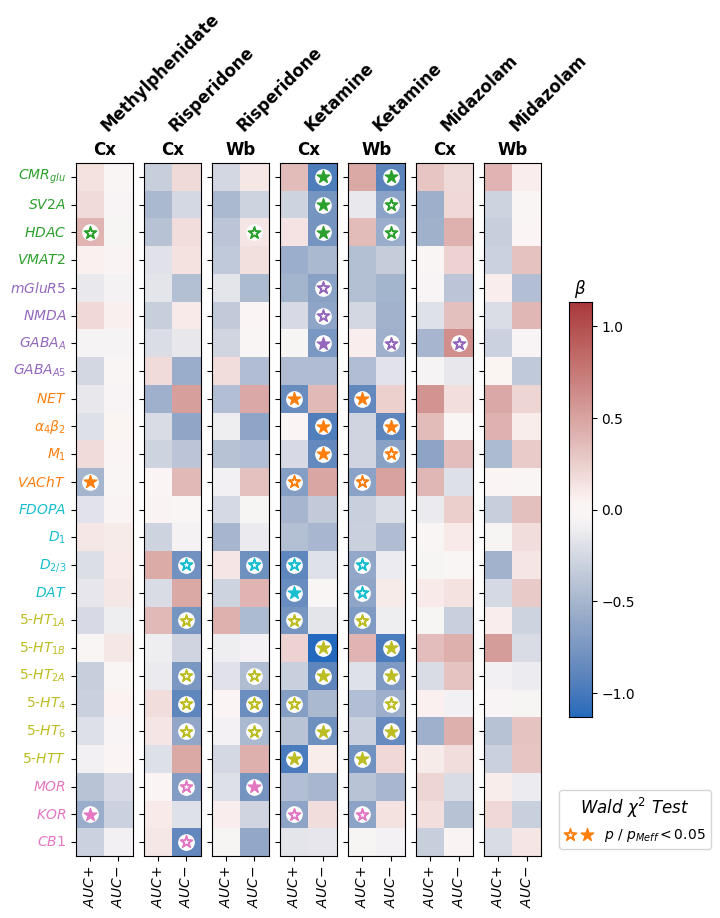

In [12]:
def plot_drug_overview(axes=None, save_path=None, drug_title=True):
    parc_cx = "Schaefer200"
    parc_wb = "Schaefer200Subcortical"
    
    # new df: maps in columns, row indexers: drug, statistic (p vs beta), parc, metric
    df_comp = pd.concat(
        {
            "mph": comp_drug_mph.query("effect == 'treat'")[["beta", "p", "pmeff"]],
            "risp": comp_drug_risp.query("effect == 'treat'")[["beta", "p", "pmeff"]],
            "ket": comp_drug_ket.query("effect == 'treat*session'")[["beta", "p", "pmeff"]],
            "mdz": comp_drug_mdz.query("effect == 'treat*session'")[["beta", "p", "pmeff"]],
        }, 
        axis=1,
        names=["drug"]
    ).unstack(["parc", "metric"]).T


    def plot_heat(df, drug, parc, ax, title=None, vmin=None, vmax=None, cbar=True):
        df = (
            df_comp
            .loc[drug, :, parc, ["original", "inverted"]][REF_NAMES_PET].copy()
            .droplevel(["drug", "parc"])
            .astype(float)
        )
        if title is None:
            title = f"{'Cx' if parc == parc_cx else 'Wb'}"
         
        # heatmap
        if cbar:
            cax = ax.inset_axes((1.5, 0.2, 0.4, 0.6))
        else:
            cax = None
        sn.heatmap(
            df.loc["beta"].T,
            ax=ax, 
            cmap="vlag", 
            vmin=vmin, 
            vmax=vmax, 
            center=0,
            cbar=cbar,
            cbar_ax=cax
        )
        
        # plot significance
        for cat, maps in REF_GROUPS_PET.items():
            # y positions
            y = [l.get_position()[1] for l in ax.get_yticklabels() if l.get_text() in maps]
            # plot markers
            for y_pos in y:
                for x_pos in range(len(ax.get_xticklabels())):
                    p = df.loc["p"].T.iloc[int(y_pos), x_pos]
                    pmeff = df.loc["pmeff"].T.iloc[int(y_pos), x_pos]
                    if p < 0.05:
                        ax.plot(x_pos+0.5, y_pos, marker="o", markersize=11, color="w")
                        ax.plot(x_pos+0.5, y_pos-0.025, marker="$★$" if pmeff < 0.05 else "$☆$", markersize=9, color=colors_by_map[maps[0]])
                    
        # layout
        sn.despine(ax=ax, left=False, bottom=False, right=False, top=False)
        if cbar:
            sn.despine(ax=cax, left=False, bottom=False, right=False, top=False)
            cax.set_title(f"$\\beta$", size=12, weight="bold")
        ax.set_title(title, size=12, weight="bold")
        ax.set_xticks(ax.get_xticks(), labels=["$AUC\t{+}$", "$AUC\t{-}$"], size=10)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # PLOT
    if axes is None:
        fig, axes = plt.subplots(1, 7, figsize=(6, 9), sharey=False, sharex=False)
    
    # color limits
    vmax = df_comp.abs().max().max()
    vmin = -vmax
    
    # plot heatmaps
    for drug, title, parc, ax in zip(
        ["mph", "risp", "risp", "ket", "ket", "mdz", "mdz"],
        ["Methylphenidate", "Risperidone", "Risperidone", "Ketamine", "Ketamine", "Midazolam", "Midazolam"],
        [parc_cx, parc_cx, parc_wb, parc_cx, parc_wb, parc_cx, parc_wb],
        axes
    ):

        # plots
        plot_heat(
            df_comp, 
            drug, 
            parc, 
            ax, 
            cbar=ax.get_subplotspec().is_last_col(),
            vmin=vmin,
            vmax=vmax
        )
        
        # layout
        if drug_title:
            ax.annotate(
                f"{title}",
                xy=(0.5, 1.05),
                xycoords="axes fraction",
                ha="left",
                va="center",
                rotation=45, 
                rotation_mode="anchor",
                fontsize=12,
                fontweight="bold",
            )
        if ax.get_subplotspec().is_first_col():
            for l in ax.get_yticklabels():
                l.set_color(colors_by_map[l.get_text()])
            ax.set_yticks(ax.get_yticks(), labels=[REF_MATH_NAMES[m] for m in REF_NAMES_PET])
        else:
            ax.set_yticklabels([])
            
    # main legend
    handles_dict = {
        "$p\ /\ p_{Meff} < 0.05$": (plt.Line2D([0], [0], color=colors_by_map["NET"], marker="$☆$", markersize=9, linestyle="None"),
                                 plt.Line2D([0], [0], color=colors_by_map["NET"], marker="$★$", markersize=9, linestyle="None"))
    }
    axes[-1].legend(
        list(handles_dict.values()), list(handles_dict.keys()), 
        title="$Wald\ \\chi^2\ Test$", loc="lower left", bbox_to_anchor=(1.2, 0.),
        title_fontproperties={'weight':'semibold', "size": 12},
        handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None)}
    )
    
    # save
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

plot_drug_overview()

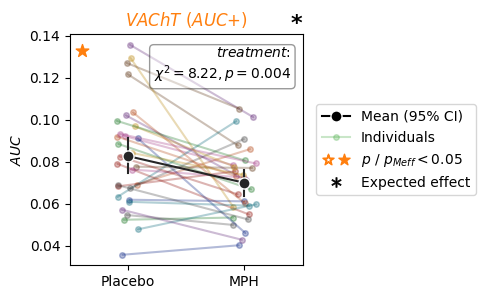

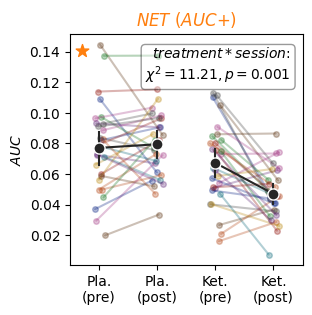

In [13]:
def plot_drug_points(df_data, df_comp, metric, effect, m, parc="Schaefer200", ax=None, asterisk=False, legend=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))

    df = (
        df_data
        .query("(parc == @parc) & (metric == @metric) & (stat == @stat)")
        .loc[:, m]
        .reset_index()
    )
    if "ses" in df.columns:
        df["treat"] = df["treat"] + "-" + df["ses"]
    df["treat"] = pd.Categorical(
        df["treat"], categories=[c for c in df["treat"].unique() if "placebo" in c] + [c for c in df["treat"].unique() if not "placebo" in c])
    #display(df)
    
    stats = (
        df_comp
        .set_index("effect", append=True)
        .loc[(parc, metric, m, effect), :]
    )
    #display(stats)
    
    dfs = [df] if effect != "treat*session" else [df.loc[df["treat"].str.contains("placebo")], df.loc[~df["treat"].str.contains("placebo")]]
    for df in dfs:
        p = (
            so.Plot(df, x="treat", y=m)
            .add(so.Line(marker="o", alpha=0.3, pointsize=4), so.Jitter(width=0.25), group="sub", color="sub", legend=False)
            .add(so.Range(color="k"), so.Est(errorbar=("ci", 95)))
            .add(so.Line(color="k", marker="o", pointsize=8, edgecolor="w"), so.Agg("mean"))
            .scale(color=so.Nominal("dark"))
            .label(x="", y=f"$AUC$", size=12)
            .on(ax)
            .plot()
        )
    
    ax.set_xticks(
        ax.get_xticks(), 
        labels=[{
            "placebo": "Placebo", 
            "risp_low": "Risp.\n(low)",
            "risp_high": "Risp.\n(high)",
            "mph": "MPH",
            "placebo-pre": "Pla.\n(pre)",
            "ketamine-pre": "Ket.\n(pre)",
            "placebo-post": "Pla.\n(post)",
            "ketamine-post": "Ket.\n(post)",
            "midazolam-pre": "Mdz.\n(pre)",
            "midazolam-post": "Mdz.\n(post)",
        }[l.get_text()] for l in ax.get_xticklabels()]
    )
    ax.set_title(REF_MATH_NAMES[m] + f" $(AUC\t{{{'+' if metric == 'original' else '-'}}})$", color=colors_by_map[m], fontsize=12)
    if asterisk:
        ax.annotate("*", xy=(1, 1.0), xycoords="axes fraction", ha="right", va="bottom", weight="bold", size=16)
    
    ax.annotate(
        f"${effect.replace('treat', 'treatment')}$:\n"
        f"$\\chi^2={stats['chi2']:.02f}, p={stats['p']:.03f}$",
        xy=(0.95,0.95),
        xycoords="axes fraction",
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="w", alpha=0.4, edgecolor="k", boxstyle="round,pad=0.3")
    )
    
    if stats["p"] < 0.05:
        ax_sig = ax.inset_axes((0, 0, 1, 1))
        ax_sig.set_axis_off()
        ax_sig.plot(0.05, 0.93, marker="$★$" if stats["pmeff"] < 0.05 else "$☆$", markersize=9, color=colors_by_map[m])
        ax_sig.set_xlim(0,1)
        ax_sig.set_ylim(0,1)
    
    if legend:
        handles_dict = {
            "Mean (95% CI)": mpl.lines.Line2D([0], [0], color="k", marker="o", markersize=8, markeredgecolor="w"),
            "Individuals": mpl.lines.Line2D([0], [0], color=sn.color_palette("Set1")[2], marker="o", markersize=4, alpha=0.3),
            "$p\ /\ p_{Meff} < 0.05$": (mpl.lines.Line2D([0], [0], linestyle="none", marker="$☆$", markersize=8, color=colors_by_map[m]), 
                                        mpl.lines.Line2D([0], [0], linestyle="none", marker="$★$", markersize=8, color=colors_by_map[m]))
        } 
        if asterisk:
           handles_dict["Expected effect"] = mpl.lines.Line2D([0], [0], linestyle="none", marker="$*$", markersize=7, markeredgewidth=0.5, color="k")
        ax.legend(handles_dict.values(), handles_dict.keys(), loc="center left", bbox_to_anchor=(1.03, 0.5),
                  handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None)})
        
        
plot_drug_points(df_drug_mph, comp_drug_mph, "original", "treat", "VAChT", legend=True, asterisk=True)
# plt.show()
plot_drug_points(df_drug_ket, comp_drug_ket, "original", "treat*session", "NET")

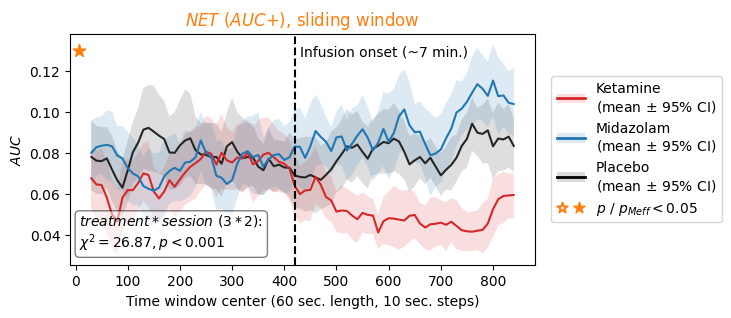

In [14]:
def plot_ketmdz_timecourse(metric, m, parc="Schaefer200", ax=None, legend=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3))
        
    df = pd.concat([
        neofc_drug_ket_indivstats_tw.loc[(parc, "pearson", "all", slice(None), metric, "auc", "val", slice(None)), m],
        neofc_drug_mdz_indivstats_tw.loc[(parc, "pearson", "all", "midazolam", metric, "auc", "val", slice(None)), m]
    ], axis=0)
    df = df.droplevel(["parc", "measure", "connections", "metric", "stat", "variable"]).reset_index()
    df["sub"] = df["id"].str.split("_").str[0]
    df["window"] = df["id"].str.split("_").str[1].str.split("-").str[1].astype(int) + 30
    
    stats_ket = comp_drug_ket.set_index("effect", append=True).loc[(parc, metric, m, "treat*session"), :]
    stats_mdz = comp_drug_mdz.set_index("effect", append=True).loc[(parc, metric, m, "treat*session"), :]
    stats_kedmdz = comp_drug_ketmdz.set_index("effect", append=True).loc[(parc, metric, m, "treat*session"), :]
    
    # colors
    colors = {
        "ketamine": "tab:red",
        "midazolam": "tab:blue",
        "placebo": "k"
    }
    
    p = (
        so.Plot(df, x="window", y=m, color="treat")
        .add(so.Band(alpha=0.15), so.Est(errorbar=("ci", 95)), legend=False)
        .add(so.Line(), so.Agg("mean"), legend=False)
        .scale(color=so.Nominal(colors))
        .label(x="Time window center (60 sec. length, 10 sec. steps)", y="$AUC$")
        .on(ax)
        .plot()
    )
    
    ax.axvline(x=7*60, color="k", linestyle="--")
    ax.annotate(
        "Infusion onset (~7 min.)", 
        xy=(7*60 + 10, ax.get_ylim()[1] - np.diff(ax.get_ylim()) * 0.05), 
        xycoords="data", 
        ha="left", 
        va="top", 
        fontsize=10
    )
    
    #  # midazolam: top left
    # ax.annotate(
    #     f"$treatment*session$:\n"
    #     f"Mdz: $\\chi^2={stats_mdz['chi2']:.02f}, p={stats_mdz['p']:.03f}$",
    #     xy=(0.05,0.95),
    #     xycoords="axes fraction",
    #     ha="left",
    #     va="top",
    #     fontsize=10,
    #     bbox=dict(facecolor="w", alpha=0.4, edgecolor="k", boxstyle="round,pad=0.3")
    # )
    # # ketamine: bottom left
    # ax.annotate(
    #     f"Ket: $\\chi^2={stats_ket['chi2']:.02f}, p={stats_ket['p']:.03f}$",
    #     xy=(0.05,0.05),
    #     xycoords="axes fraction",
    #     ha="left",
    #     va="bottom",
    #     fontsize=10,
    #     bbox=dict(facecolor="w", alpha=0.4, edgecolor="k", boxstyle="round,pad=0.3")
    # )
    # ketamine vs . midazolam: bottom left
    p = stats_kedmdz['p']
    p = "< 0.001" if p < 0.001 else f"= {p:.03f}"
    ax.annotate(
        f"$treatment*session\ (3*2)$:\n"
        f"$\\chi^2={stats_kedmdz['chi2']:.02f}, p{p}$",
        xy=(0.02,0.05),
        xycoords="axes fraction",
        ha="left",
        va="bottom",
        fontsize=10,
        bbox=dict(facecolor="w", alpha=0.5, edgecolor="k", boxstyle="round,pad=0.3")
    )
    
    # sign star
    if stats_kedmdz["p"] < 0.05:
        ax_sig = ax.inset_axes((0, 0, 1, 1))
        ax_sig.set_axis_off()
        ax_sig.plot(0.02, 0.93, marker="$★$" if stats_kedmdz["pmeff"] < 0.05 else "$☆$", markersize=9, color=colors_by_map[m])
        ax_sig.set_xlim(0,1)
        ax_sig.set_ylim(0,1)
    
    ax.set_title(REF_MATH_NAMES[m] + f" $(AUC\t{{{'+' if metric == 'original' else '-'}}})$, sliding window", 
                 color=colors_by_map[m], fontsize=12)
    
    if legend:
        handles_dict = {
            f"{label.title()}\n(mean $\pm$ 95% CI)":  (
                mpl.lines.Line2D([0], [0], color=color, linewidth=2, marker="none"),
                mpl.patches.Patch(facecolor=color, alpha=0.15)
            )
            for label, color in colors.items()
        }
        star_handle =  (
            mpl.lines.Line2D([0], [0], linestyle="none", marker="$☆$", markersize=8, color=colors_by_map[m]), 
            mpl.lines.Line2D([0], [0], linestyle="none", marker="$★$", markersize=8, color=colors_by_map[m])
        )
        handles_dict["$p\ /\ p_{Meff} < 0.05$"] = star_handle
        ax.legend(list(handles_dict.values()), list(handles_dict.keys()), loc="center left", bbox_to_anchor=(1.02, 0.5),
                  handler_map={star_handle: mpl.legend_handler.HandlerTuple(ndivide=None)})
    
plot_ketmdz_timecourse("original", "NET", legend=True)

### Main plot

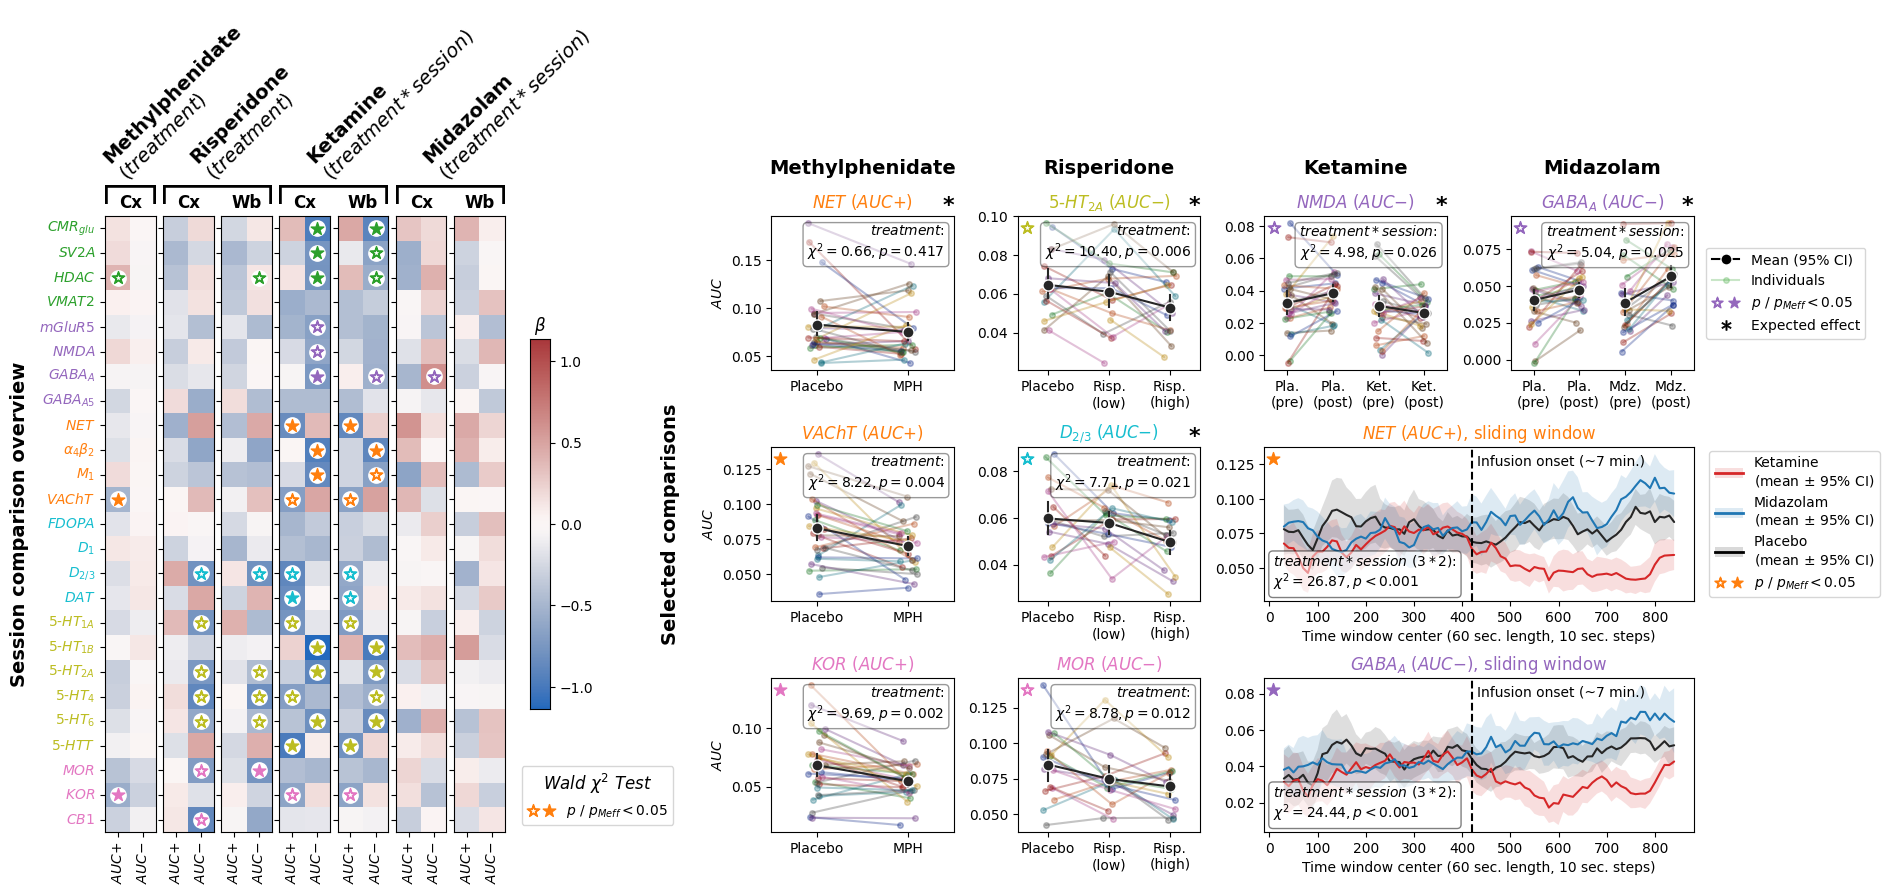

In [15]:
fig = plt.figure(figsize=(20.5, 8))

# plot bars
gs1 = fig.add_gridspec(1, 7, right=0.32, wspace=0.15)
plot_drug_overview([fig.add_subplot(gs1[0, i]) for i in range(7)], drug_title=False)

# drug labels
for drug, ax in [
    ("Methylphenidate\n$(treatment)$", fig.add_subplot(gs1[0, 0])),
    ("Risperidone\n$(treatment)$", fig.add_subplot(gs1[0, 1:3])),
    ("Ketamine\n$(treatment*session)$", fig.add_subplot(gs1[0, 3:5])),
    ("Midazolam\n$(treatment*session)$", fig.add_subplot(gs1[0, 5:7]))
]:
    ax.set_axis_off()
    if ax.get_subplotspec().is_first_col():
        ax.annotate("Session comparison overview", xy=(-1.5, 0.5), xycoords="axes fraction", ha="right", va="center", rotation=90, size=14, weight="bold")
    ax_annot = ax.inset_axes((0, 1.02, 1, 0.03))
    ax_annot.margins(0,0)
    ax_annot.set_axis_off()
    ax_annot.plot([0,0,1,1], [0,1,1,0], color="k", lw=4)
    ax_annot.annotate(drug, xy=(0.5, 1.05), xycoords="axes fraction", ha="left", va="bottom", rotation=45, rotation_mode="anchor", fontsize=14, fontweight="bold")

# plot points
gs2 = fig.add_gridspec(3, 4, left=0.45, wspace=0.35, hspace=0.5)

# MPH - Expected: NET, other: VAChT (because kind of related to NET), KOR (because strong)
ax1, ax2, ax3 = fig.add_subplot(gs2[0, 0]), fig.add_subplot(gs2[1, 0]), fig.add_subplot(gs2[2, 0])
plot_drug_points(df_drug_mph, comp_drug_mph, metric="original", effect="treat", m="NET", ax=ax1, asterisk=True)
plot_drug_points(df_drug_mph, comp_drug_mph, metric="original", effect="treat", m="VAChT", ax=ax2)
plot_drug_points(df_drug_mph, comp_drug_mph, metric="original", effect="treat", m="KOR", ax=ax3)
ax1.annotate("Methylphenidate", xy=(0.5, 1.25), xycoords="axes fraction", ha="center", va="bottom", 
             fontsize=14, fontweight="bold")
ax2.annotate("Selected comparisons", xy=(-0.5, 0.5), xycoords="axes fraction", ha="right", va="center", rotation=90, size=14, weight="bold")

# RISP - Expected: 5HT2a, other: D23 (because strong and expected), MOR (because strong)
ax1, ax2, ax3 = fig.add_subplot(gs2[0, 1]), fig.add_subplot(gs2[1, 1]), fig.add_subplot(gs2[2, 1])
plot_drug_points(df_drug_risp, comp_drug_risp, metric="inverted", effect="treat", m="5HT2a", ax=ax1, asterisk=True)
plot_drug_points(df_drug_risp, comp_drug_risp, metric="inverted", effect="treat", m="D23", ax=ax2, asterisk=True)
plot_drug_points(df_drug_risp, comp_drug_risp, metric="inverted", effect="treat", m="MOR", ax=ax3)
ax1.annotate("Risperidone", xy=(0.5, 1.25), xycoords="axes fraction", ha="center", va="bottom", 
             fontsize=14, fontweight="bold")
ax1.set_ylabel("")
ax2.set_ylabel("")
ax3.set_ylabel("")

# KET - Expected: NMDA, found: many
# quite interesting: both ketamine and midazolam show effects on NET and GABAa?
ax1 = fig.add_subplot(gs2[0, 2])
plot_drug_points(df_drug_ket, comp_drug_ket, metric="inverted", effect="treat*session", m="NMDA", ax=ax1, asterisk=True)
ax1.annotate("Ketamine", xy=(0.5, 1.25), xycoords="axes fraction", ha="center", va="bottom", 
             fontsize=14, fontweight="bold")
ax1.set_ylabel("")

# MDZ - Expected: GABAa, found: not much, weak effect for GABAa
ax1 = fig.add_subplot(gs2[0, 3])
plot_drug_points(df_drug_mdz, comp_drug_mdz, metric="inverted", effect="treat*session", m="GABAa", ax=ax1, asterisk=True, legend=True)
ax1.annotate("Midazolam", xy=(0.5, 1.25), xycoords="axes fraction", ha="center", va="bottom", 
             fontsize=14, fontweight="bold")
ax1.set_ylabel("")

# KET & MDZ - timecourses
ax1, ax2 = fig.add_subplot(gs2[1, 2:]), fig.add_subplot(gs2[2, 2:])
plot_ketmdz_timecourse("original", "NET", ax=ax1, legend=True)
plot_ketmdz_timecourse("inverted", "GABAa", ax=ax2, legend=False)
ax1.set_ylabel("")
ax2.set_ylabel("")

# save
fig.savefig(wd / "plots" / "drug" / f"drugeffects_parc-{parc_cx}.pdf", bbox_inches="tight")
